# Low-Risk Anomaly 프로젝트 - 데이터 수집

## 전체 파이프라인
1. **유니버스 구성**: S&P500 역사적 구성 종목 (생존편향 완화)
2. **가격 데이터**: yfinance (일별 OHLCV) + 오염 티커 탐지 및 제거
3. **피처 계산**: vol, beta, mcap, 월별 수익률
4. **월별 패널**: monthly_panel.csv — BL 백테스트용
5. **데이터 품질 확인**
6. **보조 데이터**: 섹터 ETF / Fama-French / 매크로 (레짐 분석 및 BL Q 계산용)

## 패널 변수 (monthly_panel.csv)
| 변수 | 설명 | 용도 |
|------|------|------|
| vol_21d | 21일 실현변동성 | P 분류 기준 |
| vol_60d | 60일 실현변동성 | EDA |
| vol_252d | 252일 실현변동성 | 저위험 분류 기준 |
| beta_252d | 252일 CAPM 베타 (vs SPY) | 저위험 분류 기준 |
| log_mcap | 로그 시가총액 | BL P 행렬 가중치 |
| gics_sector | GICS 섹터 | 섹터 분석 |
| ret_1m | 월별 수익률 | 성과 검증 |
| fwd_ret_1m | 다음달 수익률 | 성과 검증 |
| spy_ret | SPY 월별 수익률 | 벤치마크 |
| rf_1m | 무위험수익률 (월별) | 초과수익 계산 |

## 설계 결정사항
- **생존편향**: Wikipedia S&P500 변경 히스토리 역방향 재구성
- **중복 티커**: GOOG → GOOGL, BRK.A → BRK.B
- **오염 티커 제거**: 극단 가격 변화(10배+) 및 연속 0 수익률(60일+) 시각화 후 제거
- **일별 수익률**: daily_returns.pkl — 공분산 추정용 (prices_raw.pkl Close의 로그수익률 사전 저장본)

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import pickle
import time
import warnings
import platform
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

warnings.filterwarnings('ignore')

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'data'
DATA_DIR.mkdir(parents=True, exist_ok=True)

# PRICE_START : 2004-01-01 → rolling(252) 워밍업 + ret_1m 첫 행 확보
# PRICE_END   : 2026-03-31 → 2025-12 fwd_ret_1m 계산을 위해 1분기 더 수집
# PANEL_START : 2005-01-01 → START_PRED=2010 기준 60개월 훈련 데이터 확보
# PANEL_END   : 2024-12-31 → 실제 분석 패널 종료
PRICE_START = '2004-01-01'
PRICE_END   = '2026-03-31'
PANEL_START = '2005-01-01'
PANEL_END   = '2024-12-31'

print(f'데이터 경로: {DATA_DIR}')
print(f'가격 수집 기간: {PRICE_START} ~ {PRICE_END}')
print(f'패널 기간:     {PANEL_START} ~ {PANEL_END}')
print(f'→ TRAIN_WINDOW=60개월 시 2010-01부터 예측 가능 (훈련 데이터 확보)')

데이터 경로: c:\workspace\camp\project\finance_project\서윤범\low_risk\data
가격 수집 기간: 2004-01-01 ~ 2026-03-31
패널 기간:     2005-01-01 ~ 2024-12-31
→ TRAIN_WINDOW=60개월 시 2010-01부터 예측 가능 (훈련 데이터 확보)


# 1. S&P500 유니버스 구성 (생존편향 완화)

## 핵심 아이디어
- Wikipedia S&P500 현재 구성 + 변경 히스토리 → **역방향 재구성**
- 매월 "그 시점에 실제로 편입되어 있던 종목"만 패널에 포함
- 상장폐지/편출된 종목도 포함 → 생존편향 완화

## GOOGL/GOOG 중복 문제
- Alphabet은 GOOGL(Class A)과 GOOG(Class C) 두 종목이 모두 S&P500에 편입
- 같은 회사를 두 번 포함하면 공분산 행렬 추정에 왜곡 발생
- **해결**: GOOGL만 사용, GOOG 제거
- 같은 이유로 BRK.A → BRK.B만 사용

In [2]:
import requests
from bs4 import BeautifulSoup

DUPLICATE_DROP = {'GOOG', 'BRK.A'}

URL     = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
HEADERS = {'User-Agent': 'Mozilla/5.0 (compatible; research-bot/1.0)'}

def fetch_sp500_tables():
    """Wikipedia S&P500 페이지에서 wikitable 2개 반환"""
    resp = requests.get(URL, headers=HEADERS, timeout=30)
    resp.raise_for_status()
    soup   = BeautifulSoup(resp.text, 'html.parser')
    tables = soup.find_all('table', {'class': 'wikitable'})
    if len(tables) < 2:
        raise ValueError(f"테이블 {len(tables)}개만 발견 (최소 2개 필요) — Wikipedia 구조 변경 가능성")
    return tables

def parse_current_sp500(table) -> pd.DataFrame:
    df = pd.read_html(str(table))[0]
    df.columns = [c.lower().replace(' ', '_') for c in df.columns]
    col_map = {}
    for c in df.columns:
        if 'symbol' in c or 'ticker' in c: col_map[c] = 'ticker'
        if 'gics_sector' in c or 'sector' in c: col_map[c] = 'gics_sector'
    df = df.rename(columns=col_map)
    df['ticker'] = df['ticker'].str.replace('.', '-', regex=False).str.strip()
    return df[['ticker', 'gics_sector']].drop_duplicates('ticker')

def parse_changes(table) -> pd.DataFrame:
    df = pd.read_html(str(table))[0]
    df.columns = ['_'.join(str(c).lower().split()) for c in df.columns]

    date_col    = next((c for c in df.columns if 'date'  in c), None)
    added_col   = next((c for c in df.columns if 'added'  in c and 'ticker' in c), None)
    removed_col = next((c for c in df.columns if 'remov'  in c and 'ticker' in c), None)

    if date_col is None:
        return pd.DataFrame(columns=['date', 'added', 'removed'])

    df = df[[date_col,
             added_col   if added_col   else df.columns[0],
             removed_col if removed_col else df.columns[0]]].copy()
    df.columns = ['date', 'added', 'removed']
    df['date']    = pd.to_datetime(df['date'], errors='coerce')
    df            = df.dropna(subset=['date'])
    df['added']   = df['added'].astype(str).str.replace('.', '-', regex=False).str.strip()
    df['removed'] = df['removed'].astype(str).str.replace('.', '-', regex=False).str.strip()
    return df

def build_monthly_membership(df_current, df_changes, start, end) -> dict:
    """
    역방향 재구성: 현재 구성에서 시작해 변경 이벤트를 거꾸로 적용
    → 각 월말 시점의 S&P500 구성 종목 반환
    """
    monthly_dates = pd.date_range(start, end, freq='ME')
    current_set   = set(df_current['ticker'].tolist())
    membership    = {}

    for target in sorted(monthly_dates, reverse=True):
        for _, row in df_changes[df_changes['date'] > target].iterrows():
            added   = str(row['added']).strip()
            removed = str(row['removed']).strip()
            if added   and added   != 'nan': current_set.discard(added)
            if removed and removed != 'nan': current_set.add(removed)
        membership[target] = frozenset(current_set)

    return membership

# ── Wikipedia 수집 ──────────────────────────────────────
MEMBERSHIP_PATH = DATA_DIR / 'sp500_membership.pkl'

if MEMBERSHIP_PATH.exists():
    with open(MEMBERSHIP_PATH, 'rb') as f:
        sp500_membership = pickle.load(f)
    print(f"멤버십 히스토리 로드: {len(sp500_membership)}개 월")
else:
    print("Wikipedia에서 S&P500 데이터 수집 중...")
    tables     = fetch_sp500_tables()
    df_current = parse_current_sp500(tables[0])
    df_changes = parse_changes(tables[1])
    print(f"  현재 구성: {len(df_current)}종목 / 변경 이벤트: {len(df_changes)}건")

    sp500_membership = build_monthly_membership(df_current, df_changes, PRICE_START, PRICE_END)
    with open(MEMBERSHIP_PATH, 'wb') as f:
        pickle.dump(sp500_membership, f)
    print(f"  멤버십 생성 완료: {len(sp500_membership)}개 월")

Wikipedia에서 S&P500 데이터 수집 중...
  현재 구성: 503종목 / 변경 이벤트: 394건
  멤버십 생성 완료: 267개 월


In [3]:
# ── 전체 유니버스 (역사적으로 한 번이라도 편입된 종목) ────────
UNIVERSE_PATH = DATA_DIR / 'universe.csv'

if UNIVERSE_PATH.exists():
    df_universe = pd.read_csv(UNIVERSE_PATH)
    print(f"유니버스 로드: {len(df_universe)}종목")
else:
    # 현재 구성 재수집 (섹터 매핑용)
    tables     = fetch_sp500_tables()
    df_current = parse_current_sp500(tables[0])
    sector_map = dict(zip(df_current['ticker'], df_current['gics_sector']))

    # 모든 월의 멤버 합집합
    all_tickers = set()
    for members in sp500_membership.values():
        all_tickers.update(members)
    
    # GOOGL/GOOG, BRK.A/BRK.B 중복 제거
    all_tickers -= DUPLICATE_DROP
    print(f"중복 제거 후 유니버스: {len(all_tickers)}종목")
    print(f"  제거된 티커: {DUPLICATE_DROP}")

    # 현재 구성에 없는 역사적 종목 → yfinance로 섹터 보완
    need_sector = all_tickers - set(sector_map.keys())
    print(f"  섹터 미확인 종목 {len(need_sector)}개 → yfinance 조회 중...")
    
    for i, t in enumerate(sorted(need_sector)):
        try:
            info = yf.Ticker(t).info
            sec  = info.get('sector', 'Unknown')
            sector_map[t] = sec
        except:
            sector_map[t] = 'Unknown'
        if (i + 1) % 50 == 0:
            print(f"  {i+1}/{len(need_sector)} 완료")
        time.sleep(0.1)

    df_universe = pd.DataFrame([
        {'ticker': t, 'gics_sector': sector_map.get(t, 'Unknown')}
        for t in sorted(all_tickers)
    ])
    df_universe.to_csv(UNIVERSE_PATH, index=False)
    print(f"\n유니버스 저장: {len(df_universe)}종목")

# Unknown 섹터 현황 확인
n_unknown = (df_universe['gics_sector'] == 'Unknown').sum()
print(f"\n섹터 분포:")
print(df_universe['gics_sector'].value_counts().to_string())
print(f"\n⚠ Unknown 섹터: {n_unknown}개 — 유니버스에는 포함 (indmom 미사용)")

중복 제거 후 유니버스: 833종목
  제거된 티커: {'BRK.A', 'GOOG'}
  섹터 미확인 종목 332개 → yfinance 조회 중...


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ANSS"}}}


  50/332 완료


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: CMA"}}}
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: DAY"}}}
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: DNB"}}}


  100/332 완료


...

  250/332 완료


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: SRCL"}}}
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: STR"}}}


  300/332 완료


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: WBA"}}}
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: YHOO"}}}



유니버스 저장: 833종목

섹터 분포:
gics_sector
Unknown                   205
Industrials                94
Financials                 76
Information Technology     73
Health Care                58
Consumer Discretionary     48
Real Estate                36
Energy                     35
Consumer Staples           35
Consumer Cyclical          35
Utilities                  32
Communication Services     29
Materials                  26
Financial Services         17
Healthcare                 15
Technology                  9
Basic Materials             6
Consumer Defensive          4

⚠ Unknown 섹터: 205개 — 유니버스에는 포함 (indmom 미사용)


In [4]:
# ── 발행주식수 시계열 수집 (시가총액 계산용) ────────────────
SHARES_PATH = DATA_DIR / 'shares_outstanding.pkl'

if SHARES_PATH.exists():
    with open(SHARES_PATH, 'rb') as f:
        shares_map = pickle.load(f)
    print(f"발행주식수 로드: {len(shares_map)}종목")
else:
    tickers_all = df_universe['ticker'].tolist()
    shares_map  = {}
    print(f"발행주식수 수집 시작: {len(tickers_all)}종목")

    for i, t in enumerate(tickers_all):
        try:
            ts = yf.Ticker(t).get_shares_full(start=PRICE_START)
            if ts is not None and len(ts) > 0:
                shares_map[t] = ts
        except Exception:
            pass
        if (i + 1) % 100 == 0:
            print(f"  {i+1}/{len(tickers_all)} 완료 (수집 성공: {len(shares_map)}개)")
        time.sleep(0.05)

    with open(SHARES_PATH, 'wb') as f:
        pickle.dump(shares_map, f)
    print(f"\n저장 완료: {len(shares_map)}종목 / {len(tickers_all)}종목")

발행주식수 수집 시작: 833종목
  100/833 완료 (수집 성공: 95개)
  200/833 완료 (수집 성공: 188개)
  300/833 완료 (수집 성공: 283개)
  400/833 완료 (수집 성공: 377개)
  500/833 완료 (수집 성공: 468개)
  600/833 완료 (수집 성공: 561개)
  700/833 완료 (수집 성공: 656개)
  800/833 완료 (수집 성공: 751개)

저장 완료: 782종목 / 833종목


# 2. 가격 데이터 수집 (yfinance)

SPY(시장 벤치마크)와 무위험수익률(^IRX: 13주 T-bill)도 함께 수집합니다.

In [5]:
PRICES_PATH = DATA_DIR / 'prices_raw.pkl'
tickers     = df_universe['ticker'].tolist()

if PRICES_PATH.exists():
    prices_raw = pd.read_pickle(PRICES_PATH)
    print(f"가격 데이터 로드: {prices_raw.shape}")
else:
    all_symbols = ['SPY', '^IRX'] + tickers
    print(f"총 {len(all_symbols)}개 티커 다운로드 시작...")

    BATCH = 200
    dfs   = []
    for i in range(0, len(all_symbols), BATCH):
        batch = all_symbols[i:i+BATCH]
        print(f"  배치 {i//BATCH+1}: {batch[0]} ~ {batch[-1]} ({len(batch)}개)")
        df = yf.download(
            batch,
            start=PRICE_START,
            end=PRICE_END,
            auto_adjust=True,
            progress=False
        )
        dfs.append(df)
        time.sleep(1)

    prices_raw = pd.concat(dfs, axis=1)
    prices_raw = prices_raw.loc[:, ~prices_raw.columns.duplicated()]
    prices_raw.to_pickle(PRICES_PATH)
    print(f"\n저장 완료: {prices_raw.shape}")

# Close 가격 추출
if isinstance(prices_raw.columns, pd.MultiIndex):
    close = prices_raw['Close']
else:
    close = prices_raw[['Close']]

# 중복 날짜 제거 (yfinance 배치 다운로드 시 간헐적으로 발생)
n_dup = close.index.duplicated().sum()
if n_dup > 0:
    print(f"중복 날짜 {n_dup}개 제거")
    close = close[~close.index.duplicated(keep='last')]

print(f"\nClose 가격: {close.shape[0]}일 × {close.shape[1]}종목")
print(f"결측치 비율: {close.isna().mean().mean():.1%}")

총 835개 티커 다운로드 시작...
  배치 1: SPY ~ CTRA (200개)


$CEPH: possibly delisted; no price data found  (1d 2004-01-01 -> 2026-03-31)
$BHI: possibly delisted; no price data found  (1d 2004-01-01 -> 2026-03-31)
$BIG: possibly delisted; no timezone found
$COV: possibly delisted; no price data found  (1d 2004-01-01 -> 2026-03-31)
$CHK: possibly delisted; no timezone found
$AV: possibly delisted; no price data found  (1d 2004-01-01 -> 2026-03-31)
$ANR: possibly delisted; no price data found  (1d 2004-01-01 -> 2026-03-31)
$AYE: possibly delisted; no price data found  (1d 2004-01-01 -> 2026-03-31)
$AVP: possibly delisted; no timezone found
$BJS: possibly delisted; no price data found  (1d 2004-01-01 -> 2026-03-31)
$ACE: possibly delisted; no price data found  (1d 2004-01-01 -> 2026-03-31)
$BCR: possibly delisted; no price data found  (1d 2004-01-01 -> 2026-03-31)
$APOL: possibly delisted; no price data found  (1d 2004-01-01 -> 2026-03-31)
$CMCSK: possibly delisted; no price data found  (1d 2004-01-01 -> 2026-03-31)
$ADS: possibly delisted; no time

  배치 2: CTSH ~ INTC (200개)


$ETFC: possibly delisted; no timezone found
$FDC: possibly delisted; no timezone found
$HFC: possibly delisted; no timezone found
$DJ: possibly delisted; no price data found  (1d 2004-01-01 -> 2026-03-31)
$FL: possibly delisted; no timezone found
$DRE: possibly delisted; no timezone found
$DO: possibly delisted; no timezone found
$HNZ: possibly delisted; no price data found  (1d 2004-01-01 -> 2026-03-31)
$DAY: possibly delisted; no timezone found
$DF: possibly delisted; no timezone found
$GAS: possibly delisted; no price data found  (1d 2004-01-01 -> 2026-03-31)
$FRX: possibly delisted; no timezone found
$DFS: possibly delisted; no timezone found
$FDO: possibly delisted; no price data found  (1d 2004-01-01 -> 2026-03-31)
$ENDP: possibly delisted; no timezone found
$FII: possibly delisted; no timezone found
$DNR: possibly delisted; no timezone found
$ESV: possibly delisted; no timezone found
$GPS: possibly delisted; no timezone found
$CXO: possibly delisted; no timezone found
$GMCR: pos

  배치 3: INTU ~ PFG (200개)


...

  배치 4: PG ~ WEC (200개)


$PGN: possibly delisted; no price data found  (1d 2004-01-01 -> 2026-03-31)
$RHT: possibly delisted; no timezone found
$SIAL: possibly delisted; no price data found  (1d 2004-01-01 -> 2026-03-31)
$VAR: possibly delisted; no timezone found
$VIAB: possibly delisted; no timezone found
$SIVB: possibly delisted; no timezone found
$SNI: possibly delisted; no price data found  (1d 2004-01-01 -> 2026-03-31)
$WCG: possibly delisted; no timezone found
$SWN: possibly delisted; no timezone found
$SBL: possibly delisted; no price data found  (1d 2004-01-01 -> 2026-03-31)
$TRB: possibly delisted; no price data found  (1d 2004-01-01 -> 2026-03-31)
$QEP: possibly delisted; no timezone found
$RRD: possibly delisted; no timezone found
$PLL: possibly delisted; no timezone found
$TWTR: possibly delisted; no timezone found
$RAI: possibly delisted; no price data found  (1d 2004-01-01 -> 2026-03-31)
$RTN: possibly delisted; no timezone found
$SRCL: possibly delisted; no timezone found
$SWY: possibly delisted

  배치 5: WELL ~ ZTS (35개)


$WFR: possibly delisted; no price data found  (1d 2004-01-01 -> 2026-03-31)
$XEC: possibly delisted; no timezone found
$X: possibly delisted; no timezone found
$WIN: possibly delisted; no timezone found
$WPX: possibly delisted; no timezone found
$XLNX: possibly delisted; no timezone found
$XTO: possibly delisted; no price data found  (1d 2004-01-01 -> 2026-03-31)
$WFM: possibly delisted; no price data found  (1d 2004-01-01 -> 2026-03-31)
$WYN: possibly delisted; no price data found  (1d 2004-01-01 -> 2026-03-31)
$YHOO: possibly delisted; no timezone found
$XL: possibly delisted; no timezone found

11 Failed downloads:
['WFR', 'XTO', 'WFM', 'WYN']: possibly delisted; no price data found  (1d 2004-01-01 -> 2026-03-31)
['XEC', 'X', 'WIN', 'WPX', 'XLNX', 'YHOO', 'XL']: possibly delisted; no timezone found



저장 완료: (5595, 4339)

Close 가격: 5595일 × 835종목
결측치 비율: 31.6%


In [6]:
# ── 일별 가격 이상값 탐지 ────────────────────────────────
# 하루 사이 가격이 10배 이상 변하는 전환 시점 = yfinance 데이터 오류
# (예: TIE 2010-02: $11 → $20,700, ratio = 1780배)

JUMP_THRESHOLD = 10  # 하루 사이 10배 이상 변화

daily_ratio = close / close.shift(1)  # P_t / P_{t-1}
extreme_mask = (daily_ratio > JUMP_THRESHOLD) | (daily_ratio < 1 / JUMP_THRESHOLD)

# 티커별 이상값 발생 일수
bad_days_per_ticker = extreme_mask.sum()
affected = bad_days_per_ticker[bad_days_per_ticker > 0].sort_values(ascending=False)

print(f"=== 일별 가격 이상값 탐지 (기준: {JUMP_THRESHOLD}배 이상 변화) ===")
print(f"이상값 발생 티커: {len(affected)}개 / {close.shape[1]}개")
print(f"이상값 총 일수:   {int(affected.sum())}일")
print(f"\n[이상값 발생 티커 목록]")
print(affected.to_string())

=== 일별 가격 이상값 탐지 (기준: 10배 이상 변화) ===
이상값 발생 티커: 10개 / 835개
이상값 총 일수:   1106일

[이상값 발생 티커 목록]
Ticker
CBE     656
TIE     197
CFC     120
MEE      85
BMC      24
^IRX     10
CPWR      6
PTV       5
RSH       2
POM       1


=== A. 극단 수익률 (10배 이상 변화) ===
Ticker
CBE     656
TIE     197
CFC     120
MEE      85
BMC      24
CPWR      6
PTV       5
RSH       2
POM       1

=== B. 연속 0 log_return (60일 이상) ===
CPWR    393
BMC     326
MEE     213
GLK     213
CFC     149
PTV     139
HOT     122
RSH     114
SW       69
AMCR     66

=== 최종 drop 대상 (13개) ===
['AMCR', 'BMC', 'CBE', 'CFC', 'CPWR', 'GLK', 'HOT', 'MEE', 'POM', 'PTV', 'RSH', 'SW', 'TIE']


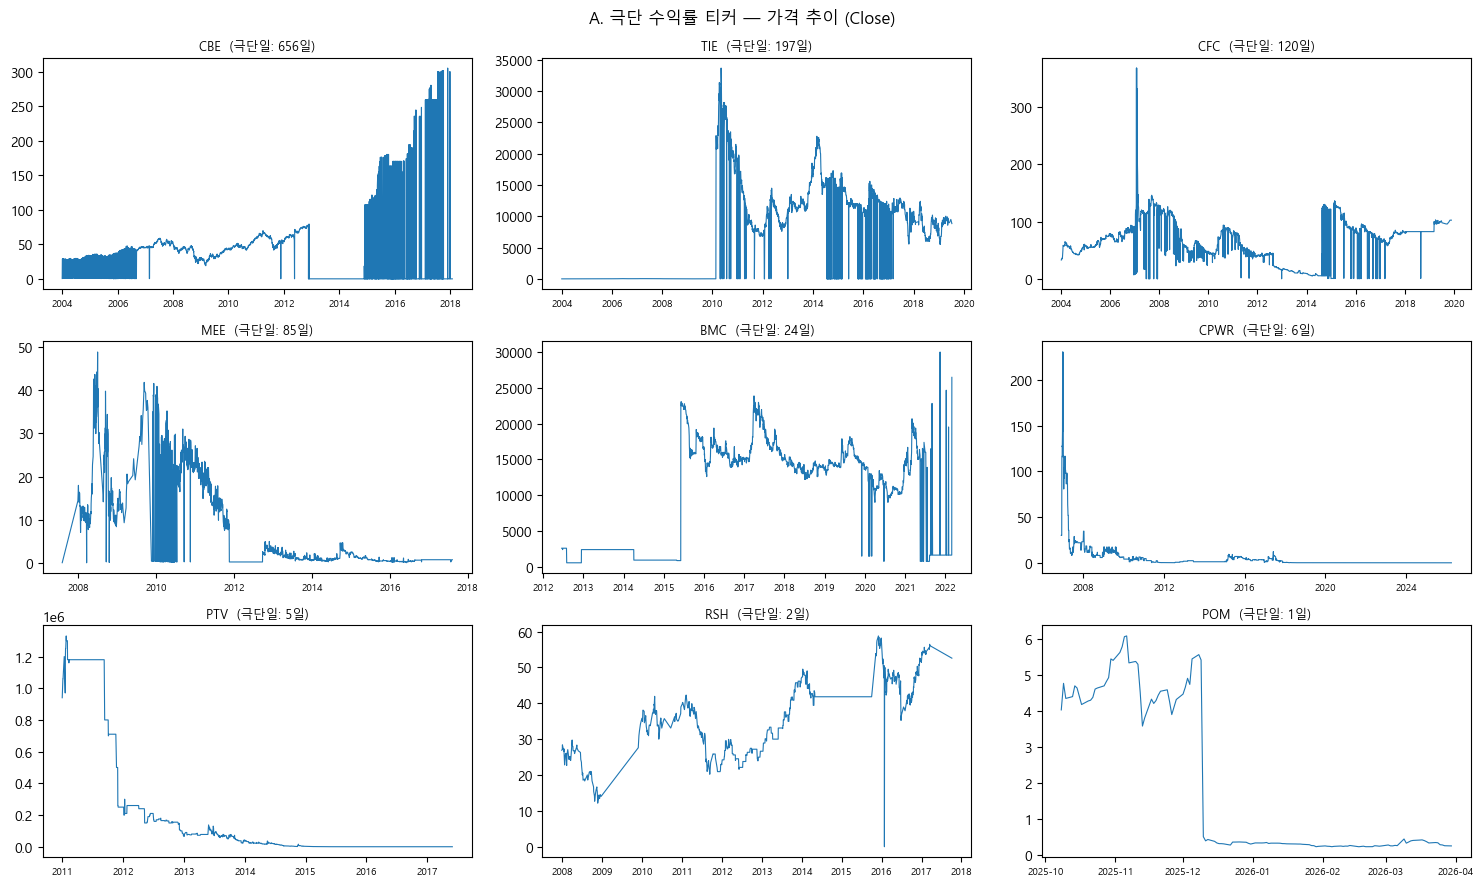

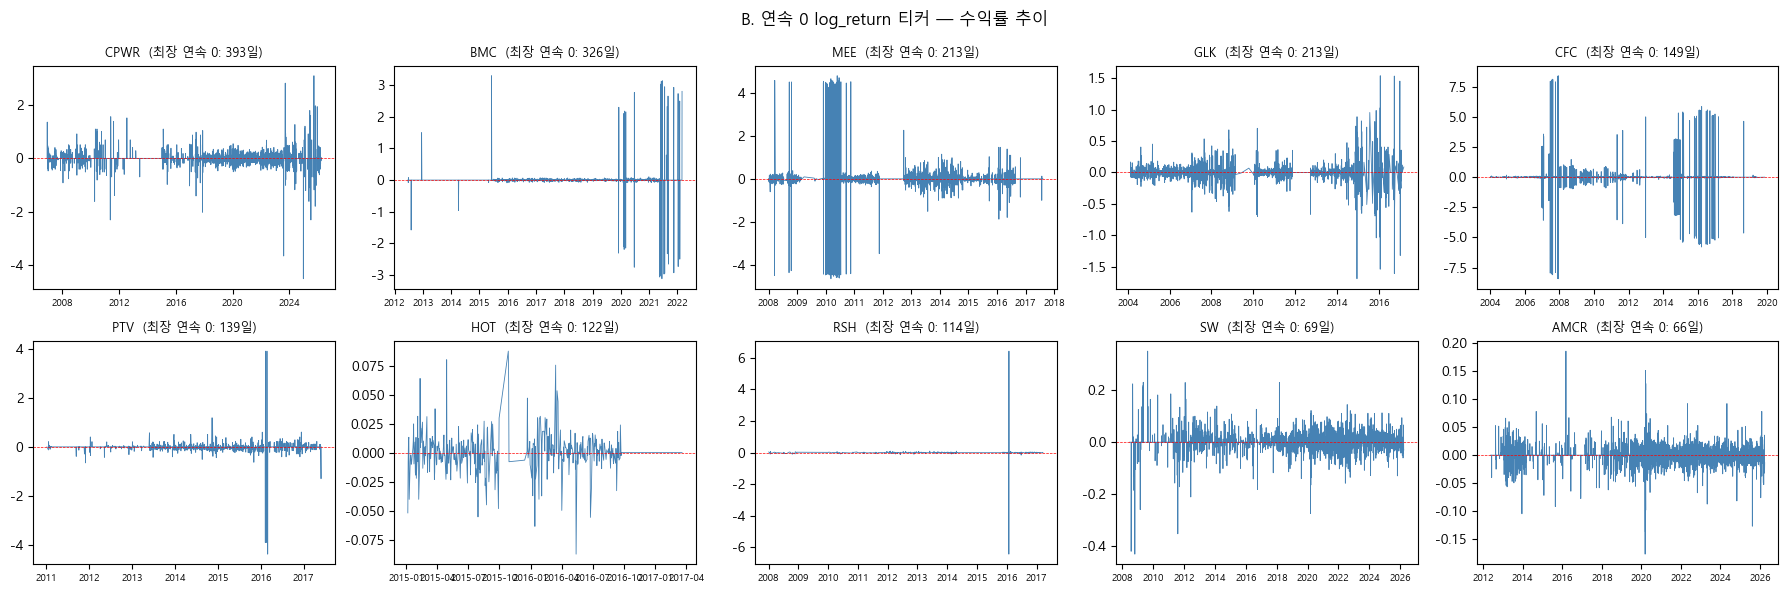

In [7]:
# ── 오염 티커 탐지 근거 시각화 ────────────────────────────────
# 제거 전에 실제로 어떤 문제인지 확인

# A: 극단 수익률 (이전 셀의 `affected` 재사용, ^IRX 제외)
bad_A = affected.drop('^IRX', errors='ignore')

# B: 연속 0 log_return
log_ret_tmp   = np.log(close / close.shift(1))
CONSEC_THRESH = 60

def _max_consec_zero(s):
    s = s.dropna()
    max_c, cur = 0, 0
    for v in (s == 0):
        cur = cur + 1 if v else 0
        max_c = max(max_c, cur)
    return max_c

consec_zeros = {t: _max_consec_zero(log_ret_tmp[t]) for t in log_ret_tmp.columns}
bad_B = pd.Series({t: v for t, v in consec_zeros.items()
                   if v >= CONSEC_THRESH}).sort_values(ascending=False)

print('=== A. 극단 수익률 (10배 이상 변화) ===')
print(bad_A.to_string())
print(f'\n=== B. 연속 0 log_return ({CONSEC_THRESH}일 이상) ===')
print(bad_B.to_string())
print(f'\n=== 최종 drop 대상 ({len(set(bad_A.index) | set(bad_B.index))}개) ===')
print(sorted(set(bad_A.index) | set(bad_B.index)))

# ── 시각화 A: 극단 수익률 가격 차트 ──────────────────────────
tickers_A = list(bad_A.index)
ncols = 3
nrows = max(1, (len(tickers_A) + ncols - 1) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3))
axes = axes.flatten()
fig.suptitle('A. 극단 수익률 티커 — 가격 추이 (Close)', fontsize=12)
for i, t in enumerate(tickers_A):
    s = close[t].dropna()
    axes[i].plot(s.index, s.values, linewidth=0.8)
    axes[i].set_title(f'{t}  (극단일: {bad_A[t]}일)', fontsize=9)
    axes[i].tick_params(axis='x', labelsize=7)
for j in range(len(tickers_A), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

# ── 시각화 B: 연속 0 수익률 차트 ─────────────────────────────
tickers_B = list(bad_B.index)
ncols = 5
nrows = max(1, (len(tickers_B) + ncols - 1) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3))
axes = axes.flatten()
fig.suptitle('B. 연속 0 log_return 티커 — 수익률 추이', fontsize=12)
for i, t in enumerate(tickers_B):
    s = log_ret_tmp[t].dropna()
    axes[i].plot(s.index, s.values, linewidth=0.6, color='steelblue')
    axes[i].axhline(0, color='r', linewidth=0.5, linestyle='--')
    axes[i].set_title(f'{t}  (최장 연속 0: {bad_B[t]}일)', fontsize=9)
    axes[i].tick_params(axis='x', labelsize=7)
for j in range(len(tickers_B), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

In [8]:

# ── 오염 티커 제거 후 prices_raw.pkl 재저장 ──────────────────
# 기준 A (자동): 하루 사이 10배 이상 가격 변화
# 기준 B (자동): 60일 이상 연속 0 log_return (티커 혼재)

# --- A. 극단 수익률 ---
drop_A = set(affected.drop('^IRX', errors='ignore').index)

# --- B. 연속 0 log_return ---
CONSEC_THRESH = 60

def _max_consec_zero(s):
    s = s.dropna()
    max_c, cur = 0, 0
    for v in (s == 0):
        cur = cur + 1 if v else 0
        max_c = max(max_c, cur)
    return max_c

log_ret_tmp  = np.log(close / close.shift(1))
consec_zeros = {t: _max_consec_zero(log_ret_tmp[t]) for t in close.columns}
drop_B       = {t for t, v in consec_zeros.items() if v >= CONSEC_THRESH}

drop_tickers = sorted((drop_A | drop_B) & set(close.columns))

# --- close 정제 ---
close = close.drop(columns=drop_tickers)

# --- prices_raw MultiIndex 컬럼에서 해당 티커 제거 후 재저장 ---
if isinstance(prices_raw.columns, pd.MultiIndex):
    keep_mask    = ~prices_raw.columns.get_level_values(1).isin(drop_tickers)
    prices_raw   = prices_raw.loc[:, keep_mask]
    volume_df    = prices_raw['Volume'].copy() if 'Volume' in prices_raw.columns.get_level_values(0) else pd.DataFrame()
    high_df      = prices_raw['High'].copy()   if 'High'   in prices_raw.columns.get_level_values(0) else pd.DataFrame()
    low_df       = prices_raw['Low'].copy()    if 'Low'    in prices_raw.columns.get_level_values(0) else pd.DataFrame()
    volume_df    = volume_df[~volume_df.index.duplicated(keep='last')] if not volume_df.empty else volume_df
    high_df      = high_df[~high_df.index.duplicated(keep='last')]     if not high_df.empty   else high_df
    low_df       = low_df[~low_df.index.duplicated(keep='last')]       if not low_df.empty    else low_df
else:
    volume_df = high_df = low_df = pd.DataFrame()

prices_raw.to_pickle(PRICES_PATH)

print(f"=== 오염 티커 제거 완료 ===")
print(f"  A (극단 수익률 10배): {sorted(drop_A)}")
print(f"  B (연속 0, {CONSEC_THRESH}일+):  {sorted(drop_B)}")
print(f"  총 제거: {len(drop_tickers)}개 → {drop_tickers}")
print(f"  close shape    : {close.shape}")
print(f"  prices_raw shape: {prices_raw.shape}")
print(f"  prices_raw.pkl 재저장 완료: {PRICES_PATH}")


=== 오염 티커 제거 완료 ===
  A (극단 수익률 10배): ['BMC', 'CBE', 'CFC', 'CPWR', 'MEE', 'POM', 'PTV', 'RSH', 'TIE']
  B (연속 0, 60일+):  ['AMCR', 'BMC', 'CFC', 'CPWR', 'GLK', 'HOT', 'MEE', 'PTV', 'RSH', 'SW']
  총 제거: 13개 → ['AMCR', 'BMC', 'CBE', 'CFC', 'CPWR', 'GLK', 'HOT', 'MEE', 'POM', 'PTV', 'RSH', 'SW', 'TIE']
  close shape    : (5595, 822)
  prices_raw shape: (5595, 4274)
  prices_raw.pkl 재저장 완료: c:\workspace\camp\project\finance_project\서윤범\low_risk\data\prices_raw.pkl


In [9]:
# Adj Close, Close, High, Low, Open, Volume
print(prices_raw.columns.get_level_values(0).unique())

# 전체 NA. 추후 제거
# Adj Close의 경우 Close에 adjust_close로 직접 수집
print(prices_raw['Adj Close'].isna().sum())

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')
Ticker
ABK     5595
ABMD    5595
ACAS    5595
ACE     5595
ADS     5595
        ... 
XEC     5595
XL      5595
XLNX    5595
XTO     5595
YHOO    5595
Length: 164, dtype: int64


# 3. 피처 계산

## 계산 로직 요약
- **수익률**: log return 사용 (덧셈 가능, 정규분포에 가까움)
- **변동성**: rolling std of log return × √252 (연환산)
- **베타**: cov(stock, SPY) / var(SPY), rolling 252일
- **시가총액**: Close × Shares Outstanding — 없으면 Close로 대체 (순위 근사치)
- **무위험수익률**: ^IRX (13주 T-bill, 연율) → 일별 변환

## Look-ahead bias 방지
- 모든 rolling 계산은 과거 데이터만 사용 (forward-looking 없음)
- 타겟 변수 `fwd_ret_1m`은 shift(-1)로 미래 수익률 참조 (타겟 변수 전용)

<Axes: xlabel='SPY', ylabel='Count'>

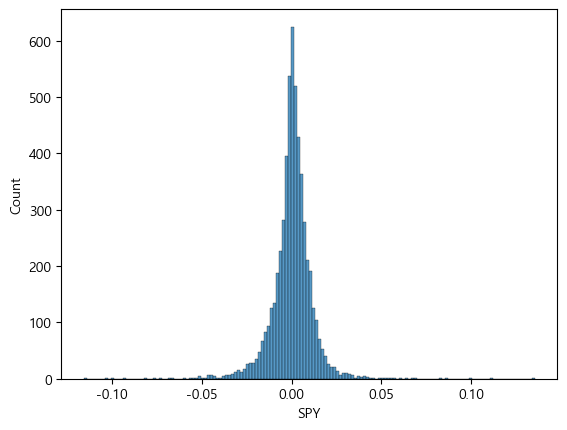

In [10]:
ANN = np.sqrt(252)

# SPY 일별 수익률 (베타 계산용)
spy_close = close['SPY']
spy_lr = np.log(spy_close / spy_close.shift(1))

sns.histplot(spy_lr)

In [11]:
ANN = np.sqrt(252)

spy_close = close['SPY']
spy_lr    = np.log(spy_close / spy_close.shift(1))

rf_annual = close['^IRX'].ffill().bfill() / 100  # NaN 5일(공휴일) ffill 처리
rf_daily  = (1 + rf_annual) ** (1/252) - 1

def compute_features(ticker: str, ac: pd.Series) -> pd.DataFrame:
    ac = ac[~ac.index.duplicated(keep='last')]

    df = pd.DataFrame(index=ac.index)

    lr  = np.log(ac / ac.shift(1))
    exc = lr - rf_daily.reindex(ac.index)
    mkt = spy_lr.reindex(ac.index)

    df['vol_21d']  = lr.rolling(21).std() * ANN
    df['vol_60d']  = lr.rolling(60).std() * ANN
    df['vol_252d'] = lr.rolling(252).std() * ANN

    cov_em          = exc.rolling(252).cov(mkt)
    var_m           = mkt.rolling(252).var()
    df['beta_252d'] = cov_em / var_m

    df['close'] = ac

    if ticker in shares_map:
        shares_ts = shares_map[ticker]
        shares_ts = shares_ts[~shares_ts.index.duplicated(keep='last')]
        if shares_ts.index.tz is not None:
            shares_ts.index = shares_ts.index.tz_localize(None)
        shares_ts = shares_ts.reindex(ac.index).ffill().bfill()
        df['log_mcap'] = np.log((ac * shares_ts).clip(lower=1))
    else:
        df['log_mcap'] = np.log(ac.clip(lower=1e-6))

    r1  = 1 + ac.pct_change()
    df['fwd_ret_1m'] = r1.shift(-1).rolling(21).apply(np.prod, raw=True).shift(-20) - 1

    df['ticker'] = ticker
    return df

print("피처 계산 함수 정의 완료")
print(f"발행주식수 보유 종목: {len(shares_map)}개 / {len(df_universe)}개")
print(f"^IRX NaN 처리: ffill().bfill() → rf_daily NaN 0개")


피처 계산 함수 정의 완료
발행주식수 보유 종목: 782개 / 833개
^IRX NaN 처리: ffill().bfill() → rf_daily NaN 0개


# 4. 월별 패널 구성

각 종목의 일별 피처를 월말(Month-End)로 리샘플링하고,  
**해당 월에 실제로 S&P500에 편입되어 있던 종목만** 패널에 포함합니다.  
(생존편향 완화의 핵심 단계)

In [12]:
PANEL_PATH = DATA_DIR / 'monthly_panel.csv'

if PANEL_PATH.exists():
    monthly_df = pd.read_csv(PANEL_PATH, parse_dates=['date'])
    monthly_df = monthly_df.set_index(['date', 'ticker'])
    print(f"패널 로드: {monthly_df.shape}")
else:
    sector_map       = dict(zip(df_universe['ticker'], df_universe['gics_sector']))
    membership_dates = sorted(sp500_membership.keys())

    def get_members_at(date: pd.Timestamp) -> frozenset:
        idx = pd.Series(membership_dates).searchsorted(date, side='right') - 1
        if idx < 0:
            return frozenset()
        return sp500_membership[membership_dates[idx]]

    monthly_panels = []
    valid_tickers  = [t for t in tickers if t in close.columns]
    print(f"피처 계산 시작: {len(valid_tickers)}종목")

    for i, ticker in enumerate(valid_tickers):
        if (i + 1) % 100 == 0:
            print(f"  {i+1}/{len(valid_tickers)} 완료")

        ac = close[ticker].dropna()
        if len(ac) < 252:
            continue

        df = compute_features(ticker, ac)

        df_m = df.resample('ME').last()
        df_m['ticker']      = ticker
        df_m['gics_sector'] = sector_map.get(ticker, 'Unknown')

        df_m = df_m[(df_m.index >= PANEL_START) & (df_m.index <= PANEL_END)]
        monthly_panels.append(df_m)

    monthly_df = pd.concat(monthly_panels)
    monthly_df.index.name = 'date'
    monthly_df = monthly_df.reset_index().set_index(['date', 'ticker'])
    monthly_df = monthly_df.sort_index()

    # ── 생존편향 필터 ────────────────────────────────────
    print("생존편향 필터 적용 중...")
    mask = [(ticker in get_members_at(date))
            for (date, ticker), _ in monthly_df.iterrows()]
    monthly_df = monthly_df[mask]
    print(f"필터 후: {monthly_df.shape[0]}행 ({monthly_df.index.get_level_values('ticker').nunique()}종목)")

    # ── SPY 월별 수익률 ───────────────────────────────────
    spy_monthly = spy_close.resample('ME').last().pct_change().rename('spy_ret')
    monthly_df  = monthly_df.join(spy_monthly, on='date')

    # ── RF 월별 환산 ──────────────────────────────────────
    rf_monthly = rf_daily.resample('ME').apply(lambda x: (1+x).prod()-1).rename('rf_1m')
    monthly_df = monthly_df.join(rf_monthly, on='date')

    # ── ret_1m: 전체 가격 히스토리로 계산 ────────────────
    monthly_close_full = close[valid_tickers].resample('ME').last()
    monthly_ret        = monthly_close_full.pct_change()
    monthly_ret        = monthly_ret.stack(future_stack=True).rename('ret_1m')
    monthly_ret.index.names = ['date', 'ticker']  # yfinance 컬럼명과 monthly_df 인덱스명 통일
    monthly_df = monthly_df.join(monthly_ret)

    monthly_df.to_csv(PANEL_PATH)
    print(f"\n패널 저장: {PANEL_PATH}")

print(f"\n최종 패널: {monthly_df.shape}")
print(f"기간: {monthly_df.index.get_level_values('date').min().date()} ~ {monthly_df.index.get_level_values('date').max().date()}")
print(f"종목 수: {monthly_df.index.get_level_values('ticker').nunique()}")
print(f"\n컬럼:")
print(monthly_df.dtypes)

피처 계산 시작: 820종목
  100/820 완료
  200/820 완료
  300/820 완료
  400/820 완료
  500/820 완료
  600/820 완료
  700/820 완료
  800/820 완료
생존편향 필터 적용 중...
필터 후: 97944행 (600종목)

패널 저장: c:\workspace\camp\project\finance_project\서윤범\low_risk\data\monthly_panel.csv

최종 패널: (97944, 11)
기간: 2005-01-31 ~ 2024-12-31
종목 수: 600

컬럼:
vol_21d        float64
vol_60d        float64
vol_252d       float64
beta_252d      float64
close          float64
log_mcap       float64
fwd_ret_1m     float64
gics_sector     object
spy_ret        float64
rf_1m          float64
ret_1m         float64
dtype: object


In [13]:
# ── 패널 기간 검증 ──────────────────────────────────────
actual_start = monthly_df.index.get_level_values('date').min()
actual_end   = monthly_df.index.get_level_values('date').max()

print(f"설정 PANEL_START : {PANEL_START}")
print(f"실제 패널 시작일 : {actual_start.date()}")
print(f"실제 패널 종료일 : {actual_end.date()}")

assert actual_start >= pd.Timestamp(PANEL_START), \
    f"패널 시작일({actual_start.date()})이 PANEL_START({PANEL_START})보다 이름!"
print("시작일 검증 OK")

설정 PANEL_START : 2005-01-01
실제 패널 시작일 : 2005-01-31
실제 패널 종료일 : 2024-12-31
시작일 검증 OK


In [14]:

# ── 일별 수익률 저장 (공분산 추정용) ─────────────────────────
# 99_baseline walk-forward에서 일별 LW 공분산 추정에 사용
# sigma_monthly = sigma_daily × 21

DAILY_RET_PATH = DATA_DIR / 'daily_returns.pkl'

daily_ret = np.log(close / close.shift(1))  # close는 이미 bad ticker 제거된 상태

daily_ret.to_pickle(DAILY_RET_PATH)

print(f'일별 수익률 저장 완료')
print(f'  shape : {daily_ret.shape}  ({daily_ret.shape[0]}거래일 × {daily_ret.shape[1]}종목)')
print(f'  기간  : {daily_ret.index[0].date()} ~ {daily_ret.index[-1].date()}')
print(f'  NaN   : {daily_ret.isna().mean().mean():.1%}')
print(f'  경로  : {DAILY_RET_PATH}')


일별 수익률 저장 완료
  shape : (5595, 822)  (5595거래일 × 822종목)
  기간  : 2004-01-02 ~ 2026-03-30
  NaN   : 31.3%
  경로  : c:\workspace\camp\project\finance_project\서윤범\low_risk\data\daily_returns.pkl


# 5. 데이터 품질 확인

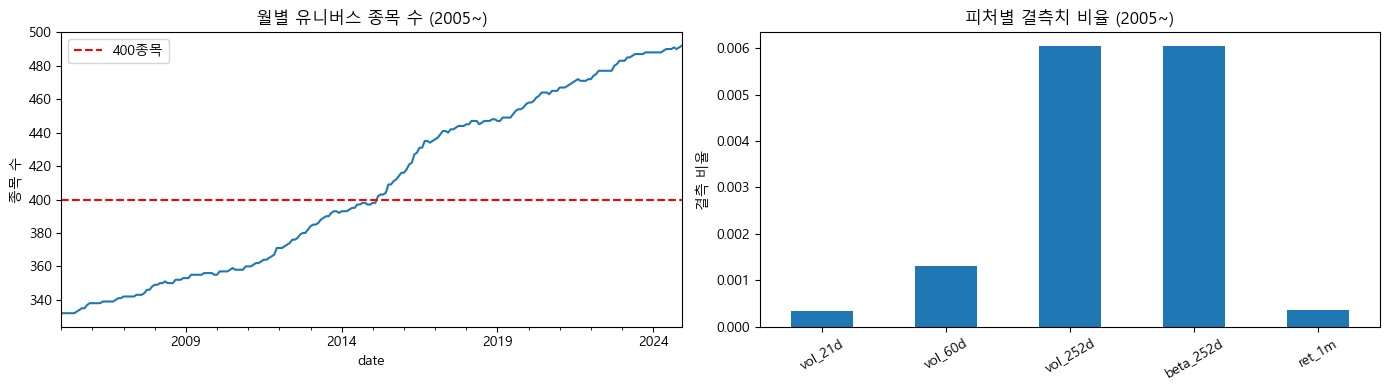

=== 2005년 이후 결측치 수 ===
vol_21d         32
vol_60d        127
vol_252d       592
beta_252d      592
close            0
log_mcap         0
fwd_ret_1m       3
gics_sector      0
spy_ret          0
rf_1m            0
ret_1m          34

=== 기초 통계 (2005~2026) ===
           ret_1m     vol_21d    vol_252d   beta_252d     spy_ret       rf_1m
count  97910.0000  97912.0000  97352.0000  97352.0000  97944.0000  97944.0000
mean       0.0107      0.2891      0.3093      1.0221      0.0096      0.0013
std        0.0915      0.2081      0.1734      0.4000      0.0434      0.0015
min       -0.8435      0.0000      0.0905     -1.6255     -0.1652      0.0000
25%       -0.0369      0.1735      0.2054      0.7657     -0.0157      0.0001
50%        0.0112      0.2375      0.2645      0.9963      0.0151      0.0004
75%        0.0570      0.3337      0.3590      1.2483      0.0365      0.0023
max        2.4498      4.8805      2.8059      3.9243      0.1270      0.0047

=== 유니버스 → 패널 종목 수 흐름 ===
  유니버스 전체:  

In [15]:
import matplotlib.pyplot as plt

# 분석 기간 데이터만 사용 (PANEL_START 이후)
panel_dates = monthly_df.index.get_level_values('date')
df_plot = monthly_df[panel_dates >= PANEL_START]

# ── 1. 월별 종목 수 추이 ──────────────────────────────────
monthly_counts = df_plot.groupby(level='date').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

monthly_counts.plot(ax=axes[0], title=f'월별 유니버스 종목 수 ({PANEL_START[:4]}~)')
axes[0].axhline(400, color='r', linestyle='--', label='400종목')
axes[0].set_ylabel('종목 수')
axes[0].legend()

# ── 2. 결측치 비율 (PANEL_START 이후 기준) ───────────────
na_rate = df_plot[['vol_21d','vol_60d','vol_252d','beta_252d','ret_1m']].isna().mean()
na_rate.plot(kind='bar', ax=axes[1], title=f'피처별 결측치 비율 ({PANEL_START[:4]}~)')
axes[1].set_ylabel('결측 비율')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# ── 2-1. 결측치 수 (PANEL_START 이후) ────────────────────
print(f"=== {PANEL_START[:4]}년 이후 결측치 수 ===")
print(df_plot.isna().sum().to_string())

# ── 3. 기초 통계 (PANEL_START 이후 기준) ─────────────────
print(f"\n=== 기초 통계 ({PANEL_START[:4]}~{PRICE_END[:4]}) ===")
print(df_plot[['ret_1m','vol_21d','vol_252d','beta_252d','spy_ret','rf_1m']].describe().round(4))

# ── 4. 유니버스 → 패널 종목 수 흐름 ──────────────────────
tickers_in_panel = set(monthly_df.index.get_level_values('ticker'))
n_universe       = len(df_universe)
n_no_price       = sum(close[t].isna().all() for t in df_universe['ticker'] if t in close.columns)
n_short          = sum(1 for t in df_universe['ticker']
                       if t in close.columns and 0 < len(close[t].dropna()) < 252)
n_panel          = len(tickers_in_panel)

print(f"\n=== 유니버스 → 패널 종목 수 흐름 ===")
print(f"  유니버스 전체:       {n_universe}종목")
print(f"  가격 데이터 전무:   -{n_no_price}종목  (yfinance에 데이터 없음)")
print(f"  데이터 252일 미만:  -{n_short}종목  (상장기간 짧음)")
print(f"  최종 패널 종목 수:   {n_panel}종목")

# ── 5. Unknown 섹터 잔존 현황 ─────────────────────────────
unknown_tickers = set(df_universe.loc[df_universe['gics_sector'] == 'Unknown', 'ticker'])
n_unknown_total = len(unknown_tickers)
n_unknown_panel = len(unknown_tickers & tickers_in_panel)

print(f"\n=== Unknown 섹터 현황 ===")
print(f"  유니버스 내 Unknown:   {n_unknown_total}종목")
print(f"  패널에 잔존한 Unknown: {n_unknown_panel}종목  (가격 데이터 있어 포함)")
print(f"  필터링된 Unknown:      {n_unknown_total - n_unknown_panel}종목")

# ── 6. GOOGL/GOOG 중복 제거 확인 ─────────────────────────
print(f"\n=== 중복 제거 확인 ===")
print(f"  GOOG  포함: {'GOOG'  in tickers_in_panel}")
print(f"  GOOGL 포함: {'GOOGL' in tickers_in_panel}")
print(f"  BRK-A 포함: {'BRK-A' in tickers_in_panel}")
print(f"  BRK-B 포함: {'BRK-B' in tickers_in_panel}")

In [16]:
sizes = pd.Series({date: len(members) for date, members in sp500_membership.items()})
sizes = sizes.sort_index()
print("월별 S&P500 멤버십 크기:")
print(sizes.describe().round(0))
print(sizes.head(10))
print(sizes.tail(10))

월별 S&P500 멤버십 크기:
count    267.0
mean     508.0
std        4.0
min      503.0
25%      506.0
50%      507.0
75%      511.0
max      516.0
dtype: float64
2004-01-31    515
2004-02-29    515
2004-03-31    515
2004-04-30    515
2004-05-31    515
2004-06-30    515
2004-07-31    515
2004-08-31    515
2004-09-30    515
2004-10-31    515
dtype: int64
2025-06-30    503
2025-07-31    503
2025-08-31    503
2025-09-30    503
2025-10-31    503
2025-11-30    503
2025-12-31    503
2026-01-31    503
2026-02-28    503
2026-03-31    503
dtype: int64


In [17]:
nan_count = sum(prices_raw['Close'].isna().all())
print(f"all-NaN 티커: {nan_count}개")

all-NaN 티커: 164개


# 6. 보조 데이터 수집 (섹터 ETF / Fama-French / 매크로)

모두 캐시 파일이 존재하면 스킵합니다.

| 데이터 | 파일 | 용도 |
|---|---|---|
| 섹터 ETF | `sector_etf.pkl` | 섹터별 12개월 수익률 (indmom) |
| FF5 일별 | `ff_factors_daily.csv` | rf_daily, mkt_rf (Q_ff3 계산용) |
| FF3 월별 | `ff3_monthly.csv` | rf_monthly (BL Q 추정용) |
| FF5 월별 | `ff5_monthly.csv` | 팩터 수익률 시계열 |
| 매크로 | `macro_daily.csv` | vix, t10y2y, dxy 등 (레짐 분류용) |

In [18]:
import io, zipfile, re

# ── 멤버십 헬퍼 (Section 1 캐시 재사용) ──────────────────────
import bisect
_membership_dates_ml = sorted(sp500_membership.keys())
def get_members_at(date):
    idx = bisect.bisect_right(_membership_dates_ml, date) - 1
    return sp500_membership[_membership_dates_ml[idx]] if idx >= 0 else frozenset()

# ── 섹터 ETF (indmom 계산용) ──────────────────────────────────
SECTOR_ETF_MAP = {
    'Energy': 'XLE', 'Materials': 'XLB', 'Industrials': 'XLI',
    'Consumer Discretionary': 'XLY', 'Consumer Staples': 'XLP',
    'Health Care': 'XLV', 'Financials': 'XLF', 'Information Technology': 'XLK',
    'Communication Services': 'XLC', 'Utilities': 'XLU', 'Real Estate': 'XLRE',
}
SECTOR_NORMALIZE = {
    'Consumer Cyclical': 'Consumer Discretionary', 'Consumer Defensive': 'Consumer Staples',
    'Healthcare': 'Health Care', 'Financial Services': 'Financials',
    'Technology': 'Information Technology', 'Basic Materials': 'Materials',
}
VALID_SECTORS = list(SECTOR_ETF_MAP.keys())

SECTOR_ETF_PATH = DATA_DIR / 'sector_etf.pkl'
if SECTOR_ETF_PATH.exists():
    indmom_by_sector = pickle.load(open(SECTOR_ETF_PATH, 'rb'))
    print(f'섹터 ETF 로드: {len(indmom_by_sector)}개 섹터')
else:
    print('섹터 ETF 다운로드 중...')
    etf_raw   = yf.download(list(SECTOR_ETF_MAP.values()), start=PRICE_START, end=PRICE_END,
                            auto_adjust=True, progress=False)
    etf_close = etf_raw['Close'] if isinstance(etf_raw.columns, pd.MultiIndex) else etf_raw
    indmom_by_sector = {}
    for sec, etf in SECTOR_ETF_MAP.items():
        if etf in etf_close.columns:
            r = etf_close[etf].pct_change()
            indmom_by_sector[sec] = (1 + r).rolling(252).apply(np.prod, raw=True) - 1
    pickle.dump(indmom_by_sector, open(SECTOR_ETF_PATH, 'wb'))
    print(f'섹터 ETF 저장: {len(indmom_by_sector)}개 섹터')

# ── Fama-French 팩터 ──────────────────────────────────────────
FF_DAILY_PATH   = DATA_DIR / 'ff_factors_daily.csv'
FF_MONTHLY_PATH = DATA_DIR / 'ff3_monthly.csv'
FF5M_PATH       = DATA_DIR / 'ff5_monthly.csv'

def _download_ff_zip(url, is_daily=True):
    r = requests.get(url, timeout=60); r.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(r.content)) as zf:
        raw = zf.read(zf.namelist()[0]).decode('utf-8', errors='ignore')
    lines = raw.splitlines()
    pat   = r'^\s*\d{8}\s*,' if is_daily else r'^\s*\d{6}\s*,'
    start = next(i for i, ln in enumerate(lines) if re.match(pat, ln))
    end   = next((i for i in range(start, len(lines)) if not re.match(pat, lines[i])), len(lines))
    df = pd.read_csv(io.StringIO('\n'.join(lines[start-1:end])))
    df.columns = [c.strip() for c in df.columns]
    dc = df.columns[0]
    if is_daily:
        df[dc] = pd.to_datetime(df[dc].astype(int).astype(str), format='%Y%m%d')
    else:
        df[dc] = pd.to_datetime(df[dc].astype(str), format='%Y%m') + pd.offsets.MonthEnd(0)
    return df.rename(columns={dc: 'date'}).set_index('date').astype(float) / 100.0

if FF_DAILY_PATH.exists():
    df_ff = pd.read_csv(FF_DAILY_PATH, index_col='date', parse_dates=True)
    print(f'FF 일별 캐시: {df_ff.shape}')
else:
    print('FF5 + MOM 일별 다운로드 중...')
    df_ff5 = _download_ff_zip('https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_daily_CSV.zip')
    df_ff5 = df_ff5.rename(columns={'Mkt-RF':'mkt_rf','SMB':'smb','HML':'hml','RMW':'rmw','CMA':'cma','RF':'rf'})
    df_mom = _download_ff_zip('https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Momentum_Factor_daily_CSV.zip')
    df_mom = df_mom.rename(columns={df_mom.columns[0]: 'mom_factor'})
    df_ff  = df_ff5.join(df_mom[['mom_factor']], how='inner')
    df_ff  = df_ff[(df_ff.index >= pd.Timestamp(PRICE_START)) & (df_ff.index <= pd.Timestamp(PRICE_END))]
    df_ff.to_csv(FF_DAILY_PATH)
    print(f'FF 일별 저장: {df_ff.shape}')

if FF_MONTHLY_PATH.exists():
    ff3_m = pd.read_csv(FF_MONTHLY_PATH, index_col='date', parse_dates=True)
else:
    ff3_m = _download_ff_zip('https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_CSV.zip', is_daily=False)
    ff3_m = ff3_m.rename(columns={'Mkt-RF':'mkt_rf','SMB':'smb','HML':'hml','RF':'rf'})
    ff3_m.to_csv(FF_MONTHLY_PATH)

if FF5M_PATH.exists():
    ff5_m = pd.read_csv(FF5M_PATH, index_col='date', parse_dates=True)
else:
    ff5_m = _download_ff_zip('https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_CSV.zip', is_daily=False)
    ff5_m = ff5_m.rename(columns={'Mkt-RF':'mkt_rf','SMB':'smb','HML':'hml','RMW':'rmw','CMA':'cma','RF':'rf'})
    mom_m = _download_ff_zip('https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Momentum_Factor_CSV.zip', is_daily=False)
    ff5_m = ff5_m.join(mom_m.rename(columns={mom_m.columns[0]:'mom_factor'})[['mom_factor']], how='inner')
    ff5_m.to_csv(FF5M_PATH)

rf_daily_ff      = df_ff['rf'].reindex(spy_close.index).ffill()
mkt_rf_daily     = df_ff['mkt_rf'].reindex(spy_close.index).ffill()
rf_monthly_ff    = ff3_m['rf']
ff_macro_monthly = ff5_m[['mkt_rf', 'smb', 'hml', 'rmw', 'cma', 'mom_factor']]
print(f'FF 로드 완료  |  rf_daily 평균: {rf_daily_ff.mean()*252*100:.2f}% 연환산')

# ── 매크로 데이터 ─────────────────────────────────────────────
MACRO_PATH = DATA_DIR / 'macro_daily.csv'

if MACRO_PATH.exists():
    macro_raw = pd.read_csv(MACRO_PATH, index_col='date', parse_dates=True)
    print(f'매크로 캐시 로드: {macro_raw.shape}')
else:
    print('매크로 데이터 수집 중...')
    yf_macros = {'vix':'^VIX','dxy':'DX-Y.NYB','gold':'GC=F','wti_crude':'CL=F',
                 'copper':'HG=F','silver':'SI=F','skew_idx':'^SKEW','t10y':'^TNX','t2y':'^IRX'}
    yf_df = yf.download(list(yf_macros.values()), start=PRICE_START, end=PRICE_END,
                        auto_adjust=True, progress=False)
    yf_m  = yf_df['Close'].copy() if isinstance(yf_df.columns, pd.MultiIndex) else yf_df.copy()
    inv_map = {v: k for k, v in yf_macros.items()}
    yf_m.columns = [inv_map.get(c, c) for c in yf_m.columns]
    if 't10y' in yf_m.columns and 't2y' in yf_m.columns:
        yf_m['t10y2y'] = yf_m['t10y'] - yf_m['t2y']
        yf_m = yf_m.drop(columns=['t10y', 't2y'])
    try:
        from pandas_datareader import data as pdr
        fred_series = {'icsa':'ICSA','sahm':'SAHMREALTIME','cpi':'CPIAUCSL','unrate':'UNRATE'}
        fred_dfs = {}
        for name, code in fred_series.items():
            try:
                fred_dfs[name] = pdr.get_data_fred(code, start=PRICE_START, end=PRICE_END).squeeze()
                print(f'  FRED {name}: OK')
            except Exception as e:
                print(f'  FRED {name} 실패: {e}')
        fred_df = pd.DataFrame(fred_dfs) if fred_dfs else pd.DataFrame()
    except ImportError:
        print('  pandas_datareader 없음 (pip install pandas-datareader)')
        fred_df = pd.DataFrame()
    macro_raw = yf_m.copy()
    if not fred_df.empty:
        macro_raw = macro_raw.join(fred_df, how='left')
        fcols = [c for c in fred_df.columns if c in macro_raw.columns]
        macro_raw[fcols] = macro_raw[fcols].ffill()
    macro_raw.index.name = 'date'
    macro_raw.to_csv(MACRO_PATH)
    print(f'매크로 저장: {macro_raw.shape}')

macro_monthly = macro_raw.resample('ME').last()
print(f'매크로 컬럼: {list(macro_raw.columns)}')
print(f'[월별] NaN:\n{macro_monthly.isna().mean().round(3).to_string()}')

섹터 ETF 다운로드 중...
섹터 ETF 저장: 11개 섹터
FF5 + MOM 일별 다운로드 중...
FF 일별 저장: (5574, 7)
FF 로드 완료  |  rf_daily 평균: 1.71% 연환산
매크로 데이터 수집 중...
  FRED icsa: OK
  FRED sahm: OK
  FRED cpi: OK
  FRED unrate: OK
매크로 저장: (5615, 12)
매크로 컬럼: ['wti_crude', 'dxy', 'gold', 'copper', 'silver', 'skew_idx', 'vix', 't10y2y', 'icsa', 'sahm', 'cpi', 'unrate']
[월별] NaN:
wti_crude    0.000
dxy          0.000
gold         0.000
copper       0.000
silver       0.000
skew_idx     0.000
vix          0.000
t10y2y       0.000
icsa         1.000
sahm         0.007
cpi          0.007
unrate       0.007


# 7. 산출물 요약

| 파일 | 형식 | 내용 | 사용처 |
|---|---|---|---|
| `sp500_membership.pkl` | `dict{date: frozenset}` | 월말별 S&P500 편입 종목 | 생존편향 필터 |
| `universe.csv` | DataFrame | 833개 역사적 유니버스 + 섹터 | 전체 종목 목록 |
| `shares_outstanding.pkl` | `dict{ticker: Series}` | 일별 발행주식수 (782개) | log_mcap 계산 |
| `prices_raw.pkl` | MultiIndex DataFrame | OHLCV 일별 (오염 13개 제거 후) | 모든 계산의 원천 |
| `daily_returns.pkl` | DataFrame | 일별 로그수익률 (822종목) | LW 공분산 추정 |
| `monthly_panel.csv` | DataFrame | 월별 패널 (600종목 × 11변수) | BL 백테스트 용도 |
| `sector_etf.pkl` | `dict{sector: Series}` | 섹터 ETF 12개월 수익률 | indmom (선택) |
| `ff_factors_daily.csv` | DataFrame | FF5+MOM 일별 팩터 | Q_ff3 계산용 rf, mkt_rf |
| `ff3_monthly.csv` | DataFrame | FF3 월별 팩터 | BL Q 추정용 rf_monthly |
| `ff5_monthly.csv` | DataFrame | FF5+MOM 월별 팩터 | 팩터 수익률 참조 |
| `macro_daily.csv` | DataFrame | VIX, t10y2y, DXY 등 12개 | HMM 레짐 분류 입력 |

In [19]:
import os

files = {
    'sp500_membership.pkl' : '월말별 S&P500 편입 종목  |  dict{date: frozenset}',
    'universe.csv'         : '역사적 유니버스           |  ticker + gics_sector',
    'shares_outstanding.pkl': '발행주식수 시계열         |  dict{ticker: Series}',
    'prices_raw.pkl'       : 'OHLCV 일별 (오염 제거 후) |  MultiIndex DataFrame',
    'daily_returns.pkl'    : '일별 로그수익률            |  공분산 추정용',
    'monthly_panel.csv'    : '월별 패널                  |  BL 백테스트 핵심',
    'sector_etf.pkl'       : '섹터 ETF 수익률            |  indmom',
    'ff_factors_daily.csv' : 'FF5+MOM 일별               |  Q_ff3 계산용 rf, mkt_rf',
    'ff3_monthly.csv'      : 'FF3 월별                   |  BL Q 추정용 rf_monthly',
    'ff5_monthly.csv'      : 'FF5+MOM 월별               |  팩터 수익률 참조',
    'macro_daily.csv'      : 'VIX, t10y2y, DXY 등 12개  |  HMM 레짐 분류 입력',
}

print('=' * 70)
print('산출물 확인')
print('=' * 70)
for fname, desc in files.items():
    path = DATA_DIR / fname
    if path.exists():
        size_mb = os.path.getsize(path) / 1024 / 1024
        print(f'  ✓  {fname:<28} {size_mb:5.1f} MB   {desc}')
    else:
        print(f'  ✗  {fname:<28}  없음     {desc}')
print('=' * 70)

산출물 확인
  ✓  sp500_membership.pkl           0.5 MB   월말별 S&P500 편입 종목  |  dict{date: frozenset}
  ✓  universe.csv                   0.0 MB   역사적 유니버스           |  ticker + gics_sector
  ✓  shares_outstanding.pkl        10.0 MB   발행주식수 시계열         |  dict{ticker: Series}
  ✓  prices_raw.pkl               182.5 MB   OHLCV 일별 (오염 제거 후) |  MultiIndex DataFrame
  ✓  daily_returns.pkl             35.1 MB   일별 로그수익률            |  공분산 추정용
  ✓  monthly_panel.csv             21.4 MB   월별 패널                  |  BL 백테스트 핵심
  ✓  sector_etf.pkl                 1.0 MB   섹터 ETF 수익률            |  indmom
  ✓  ff_factors_daily.csv           0.4 MB   FF5+MOM 일별               |  Q_ff3 계산용 rf, mkt_rf
  ✓  ff3_monthly.csv                0.1 MB   FF3 월별                   |  BL Q 추정용 rf_monthly
  ✓  ff5_monthly.csv                0.1 MB   FF5+MOM 월별               |  팩터 수익률 참조
  ✓  macro_daily.csv                0.9 MB   VIX, t10y2y, DXY 등 12개  |  HMM 레짐 분류 입력
